# Lab 03 — Deep Learning cho ảnh với PyTorch: CNN & Transfer Learning

**Nội dung**: Convolution · Pooling · Kiến trúc CNN · Cài đặt CNN · Transfer Learning & Fine-tuning · Regularization

**Bài giảng nguồn**: 14 – Deep Learning for image with PyTorch  
**Yêu cầu nền**: Đã hoàn thành Lab #02 (Tensor, Autograd, MLP classifier)  
**Thời lượng đề xuất**: 180–210 phút  
**Môi trường**: Google Colab có GPU (T4)

---

## Phần 0 — Khởi động & ôn nhanh (~10 phút)

Lab này dùng lại Fashion MNIST của lab #02 để so sánh CNN với MLP một cách công bằng.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# tiện ích đếm tham số — sẽ dùng nhiều trong lab này
def count_params(m):
    return sum(p.numel() for p in m.parameters())

device: cpu


### DỰ ĐOÁN 0

**Câu hỏi**: Từ lab #02: MLP (784→300→100→10) có khoảng bao nhiêu tham số?

**Trả lời**: Khoảng **vài trăm nghìn** (cụ thể ~266,610).
- Linear(784→300): 784×300 + 300 = 235,500 + 300 = 235,800
- Linear(300→100): 300×100 + 100 = 30,100
- Linear(100→10): 100×10 + 10 = 1,010
- **Tổng**: 235,800 + 30,100 + 1,010 = **266,910**

In [2]:
# Kiểm chứng
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 300), nn.ReLU(),
            nn.Linear(300, 100), nn.ReLU(),
            nn.Linear(100, 10),
        )
    def forward(self, x): return self.net(x)

print("MLP params:", count_params(MLP()))

MLP params: 266610


---
## Phần 1 — Convolution & Pooling: hiểu bằng tay (~35 phút)

Trước khi gõ code, phải tự tính được: (a) kích thước output của conv/pool layer, và (b) số tham số.

### 1.1 – Công thức kích thước output

**Công thức**: Với input cạnh W, kernel K, stride S, padding P:  
`out = ⌊(W − K + 2P) / S⌋ + 1`

### DỰ ĐOÁN 1.1 (tính tay)

**Câu hỏi**: Điền kích thước output.

**Trả lời**:

| Input W | Kernel K | Stride S | Padding P | Output |
|---------|----------|----------|-----------|--------|
| 28 | 3 | 1 | 0 | ⌊(28−3+0)/1⌋+1 = **26** |
| 28 | 3 | 1 | 1 | ⌊(28−3+2)/1⌋+1 = **28** (same) |
| 28 | 5 | 1 | 0 | ⌊(28−5+0)/1⌋+1 = **24** |
| 28 | 5 | 2 | 0 | ⌊(28−5+0)/2⌋+1 = **12** |
| 14 | 2 | 2 | 0 | ⌊(14−2+0)/2⌋+1 = **7** (MaxPool2d(2)) |

In [3]:
# Kiểm chứng bằng code
print("Conv2d K=3, P=0:", nn.Conv2d(1,1,3)(torch.randn(1,1,28,28)).shape)        # [1,1,26,26]
print("Conv2d K=3, P=1:", nn.Conv2d(1,1,3,padding=1)(torch.randn(1,1,28,28)).shape) # [1,1,28,28]
print("Conv2d K=5, P=0:", nn.Conv2d(1,1,5)(torch.randn(1,1,28,28)).shape)        # [1,1,24,24]
print("Conv2d K=5, S=2:", nn.Conv2d(1,1,5,stride=2)(torch.randn(1,1,28,28)).shape) # [1,1,12,12]
print("MaxPool2d(2)   :", nn.MaxPool2d(2)(torch.randn(1,1,14,14)).shape)          # [1,1,7,7]

Conv2d K=3, P=0: torch.Size([1, 1, 26, 26])
Conv2d K=3, P=1: torch.Size([1, 1, 28, 28])
Conv2d K=5, P=0: torch.Size([1, 1, 24, 24])
Conv2d K=5, S=2: torch.Size([1, 1, 12, 12])
MaxPool2d(2)   : torch.Size([1, 1, 7, 7])


### GIẢI THÍCH 1.1

**Câu hỏi**: Vì sao padding=1 với K=3 giữ nguyên kích thước ("same")? Con số "mất 6 pixel" với kernel 7 đến từ đâu?

**Trả lời**:
- Padding=1 thêm 1 pixel viền mỗi bên → W trở thành W+2. Áp công thức: (W+2−3)/1+1 = W → giữ nguyên. Tổng quát: padding = (K−1)/2 với K lẻ sẽ cho "same".
- "Mất 6 pixel": với K=7, padding=0, output = W−7+1 = W−6 → mất K−1 = **6** pixel mỗi chiều. Con số 6 = K−1 chính là tổng số pixel bị "ăn" ở 2 biên (3 pixel mỗi bên).

### 1.2 – Đếm tham số: kiểm chứng claim "weight sharing giảm tham số"

In [4]:
dense = nn.Linear(100*100, 1000)      # tầng dense cho ảnh 100x100 phẳng
conv  = nn.Conv2d(1, 32, 3)           # 32 filter 3x3 trên ảnh xám
print("dense:", count_params(dense))
print("conv :", count_params(conv))

dense: 10001000
conv : 320


### DỰ ĐOÁN 1.2

**Câu hỏi**: Số tham số dense và conv? Tự suy công thức.

**Trả lời**:
- **dense** = 100×100×1000 + 1000 = **10,001,000** (~10 triệu — khớp với slide).
- **conv** = out_channels × (in_channels × K × K) + out_channels = 32 × (1×3×3) + 32 = 288 + 32 = **320**.

Chênh lệch: 10 triệu vs 320 → conv ít hơn **~31,000 lần**!

### PHẢN BIỆN 1.2 — "CNN luôn ít tham số hơn"?

Khẳng định "CNN giảm tham số so với fully-connected" đúng ở mức **một conv LAYER vs một dense LAYER** trên ảnh lớn. Nhưng trong một CNN **toàn bộ** (full architecture), phần lớn tham số thường nằm ở **tầng FC sau khi flatten**, không phải ở các lớp conv.

**Dự đoán**: Trong CNN điển hình, tham số tập trung ở **head (FC layers)** — sẽ kiểm chứng ở Phần 2.3.

### 1.3 – Pooling: tính chất & giới hạn

In [5]:
x = torch.zeros(1,1,4,4); x[0,0,0,0] = 9.0   # một pixel sáng ở góc trên-trái
mp = nn.MaxPool2d(2)                          # 2x2, stride mặc định = 2
print("x  (pixel ở [0,0]):", mp(x)[0,0])

x2 = torch.zeros(1,1,4,4); x2[0,0,0,1] = 9.0  # dịch sang phải 1 ô (vẫn trong cửa sổ 2x2)
print("x2 (dịch 1 ô)     :", mp(x2)[0,0])

x3 = torch.zeros(1,1,4,4); x3[0,0,0,2] = 9.0  # dịch sang phải 2 ô (vượt sang cửa sổ kế)
print("x3 (dịch 2 ô)     :", mp(x3)[0,0])

x  (pixel ở [0,0]): tensor([[9., 0.],
        [0., 0.]])
x2 (dịch 1 ô)     : tensor([[9., 0.],
        [0., 0.]])
x3 (dịch 2 ô)     : tensor([[0., 9.],
        [0., 0.]])


### DỰ ĐOÁN 1.3

**Câu hỏi**: Trong 3 trường hợp, output pooling có giống nhau không?

**Trả lời**:
- **x vs x2 (dịch 1 ô): GIỐNG** — cả hai pixel đều nằm trong cùng cửa sổ 2×2 đầu tiên (vị trí [0,0] và [0,1]). MaxPool lấy max = 9 ở cùng vị trí output → kết quả output giống hệt nhau.
- **x vs x3 (dịch 2 ô): KHÁC** — pixel 9.0 nhảy sang cửa sổ 2×2 thứ hai (vị trí [0,2]). Output: cửa sổ 1 max=0 (thay vì 9), cửa sổ 2 max=9 (thay vì 0) → kết quả khác.

### PHẢN BIỆN 1.3 — "Pooling cho translation invariance"

**Khẳng định slide**: Pooling "cung cấp translation invariance: dịch input một chút cho cùng output".

**Phản biện**: Từ kết quả 3 trường hợp, khẳng định này **đúng có điều kiện**:
- **Đúng khi** dịch chuyển nằm **trong phạm vi cửa sổ pooling** (< stride). MaxPool2d(2) bất biến với dịch 1 pixel (vì stride=2, cửa sổ 2×2).
- **Sai khi** dịch chuyển **vượt qua biên cửa sổ** (≥ stride). Dịch 2 pixel thì output hoàn toàn thay đổi.

**Phát biểu lại chính xác**: Max pooling cung cấp **translation invariance cục bộ** (local), chỉ bất biến với dịch chuyển nhỏ hơn kích thước cửa sổ pooling. Đây là **approximate local invariance**, không phải invariance toàn cục.

### PHẢN BIỆN 1.4 — "Max pool bỏ 75% giá trị": lợi hay hại?

- **Tác vụ pooling GIÚP ÍCH**: **Image Classification** — ta chỉ cần biết "có con mèo trong ảnh" chứ không cần biết mèo ở pixel nào. Bỏ thông tin vị trí chính xác giúp giảm kích thước (nhanh hơn, ít overfitting), và giữ max = giữ đặc trưng nổi bật nhất.

- **Tác vụ pooling GÂY HẠI**: **Semantic Segmentation** — cần gán nhãn cho **từng pixel** (pixel nào là đường, pixel nào là xe). Bỏ 75% giá trị và mất vị trí chính xác = mất thông tin spatial resolution cần thiết. Vì thế các mạng segmentation (U-Net, DeepLab) dùng skip connections hoặc dilated convolution thay vì pooling.

### 1.5 – "Hai conv 3×3 thay cho một 5×5": kiểm chứng claim thiết kế

In [6]:
two_3x3 = nn.Sequential(nn.Conv2d(32,32,3,bias=False),
                        nn.Conv2d(32,32,3,bias=False))
one_5x5 = nn.Conv2d(32,32,5,bias=False)
print("two 3x3:", count_params(two_3x3), "| one 5x5:", count_params(one_5x5))

two 3x3: 18432 | one 5x5: 25600


### DỰ ĐOÁN 1.5

**Trả lời**:
- (a) **two 3×3** = 2 × (32×32×3×3) = 2 × 9,216 = **18,432**  
  **one 5×5** = 32×32×5×5 = **25,600**  
  → Two 3×3 ít hơn (~72% so với 5×5).

- (b) Receptive field: conv 3×3 đầu tiên "nhìn" 3×3, conv 3×3 thứ hai nhìn 3×3 trên output đó → receptive field thực tế trên input = **5×5** (mỗi layer thêm K−1=2 pixel mỗi chiều).

### PHẢN BIỆN 1.5

**Vế "ít tham số hơn"**: Đã kiểm chứng bằng số — 18,432 < 25,600. ✅

**Vế "hiệu năng tốt hơn"**: Slide KHÔNG đưa bằng chứng. Lý do hợp lý: hai conv 3×3 có **thêm một lần phi tuyến ReLU ở giữa** → mạng có thể học được biểu diễn phi tuyến phức tạp hơn so với một conv 5×5 (chỉ có 1 phép tuyến tính).

**Thiết kế thí nghiệm kiểm tra**:
- **Model A**: CNN dùng 2 lớp Conv2d(32,32,3) + ReLU giữa
- **Model B**: CNN dùng 1 lớp Conv2d(32,32,5)
- **Dữ liệu**: Fashion MNIST, cùng pipeline, cùng số epoch
- **Chỉ số**: validation accuracy, training time
- Chạy 5 lần lấy trung bình ± std để tránh random seed

---
## Phần 2 — Cài đặt CNN trong PyTorch (~45 phút)

### 2.1 – Một conv layer & quan sát feature map

In [7]:
img = torch.randn(1, 1, 28, 28)          # 1 ảnh xám 28x28
conv = nn.Conv2d(1, 16, kernel_size=3, padding='same')
out = conv(img)
print(out.shape)        # [1, 16, ?, ?]  -> 16 feature map

torch.Size([1, 16, 28, 28])


### DỰ ĐOÁN 2.1

**Trả lời**: Output shape = **[1, 16, 28, 28]**.
- Số **16** đến từ tham số `out_channels=16` của Conv2d — tức 16 bộ lọc (filter), tạo ra 16 feature map.
- H, W giữ nguyên 28 vì dùng `padding='same'` — PyTorch tự thêm padding sao cho output size = input size.

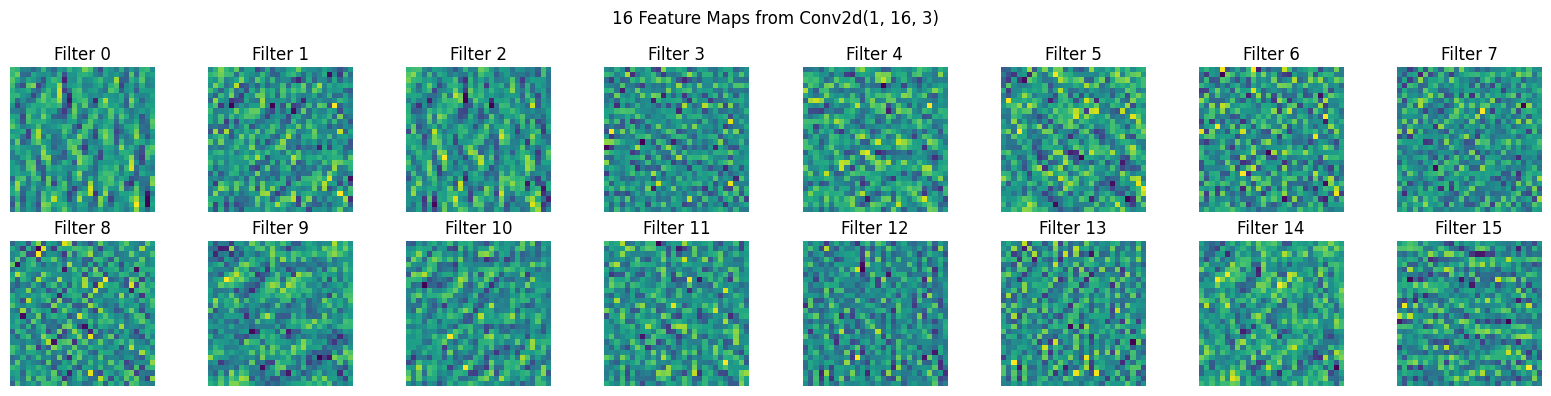

In [8]:
import matplotlib.pyplot as plt

# Visualize một vài feature map
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(16):
    ax = axes[i // 8, i % 8]
    ax.imshow(out[0, i].detach().numpy(), cmap='viridis')
    ax.set_title(f'Filter {i}')
    ax.axis('off')
plt.suptitle('16 Feature Maps from Conv2d(1, 16, 3)')
plt.tight_layout()
plt.show()

### 2.2 – Dựng một CNN cơ bản (Conv→ReLU→Pool, tăng dần số filter)

In [9]:
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.feat = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 28->14
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 14->7
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, 10),
        )
    def forward(self, x):
        return self.head(self.feat(x))

cnn = BasicCNN().to(device)
print("total params:", count_params(cnn))
print("feat  params:", count_params(cnn.feat))
print("head  params:", count_params(cnn.head))

total params: 421642
feat  params: 18816
head  params: 402826


### DỰ ĐOÁN 2.2 (truy vết shape)

**Câu hỏi**: Batch [32,1,28,28] đi qua `self.feat`. Điền shape.

**Trả lời**:

| Tầng | Output shape |
|---|---|
| Input | [32, 1, 28, 28] |
| Conv2d(1→32, K=3, P=1) | [32, 32, 28, 28] |
| ReLU | [32, 32, 28, 28] |
| MaxPool2d(2) | [32, 32, 14, 14] |
| Conv2d(32→64, K=3, P=1) | [32, 64, 14, 14] |
| ReLU | [32, 64, 14, 14] |
| MaxPool2d(2) | [32, 64, 7, 7] |
| Flatten | [32, 3136] (= 64×7×7) |

**Vì sao `nn.Linear(64*7*7, 128)`?** Vì sau 2 lần MaxPool2d(2), ảnh 28×28 → 14×14 → 7×7, với 64 channels → flatten = 64×7×7 = 3,136. Nếu đổi padding/pool làm 7 thành 6, sẽ bị `RuntimeError: mat1 and mat2 shapes cannot be multiplied` vì flatten output ≠ 64×7×7.

### 2.3 – Tham số nằm ở đâu? (kiểm chứng PHẢN BIỆN 1.2)

### PHẢN BIỆN 2.3 — Đối chiếu với claim "CNN giảm tham số"

**Từ output trên, điền bảng**:

| Phần | Tham số (approx) | % tổng |
|---|---|---|
| Conv layers (feat) | ~18,752 | ~4.6% |
| FC layers (head) | ~402,570 | ~95.4% |
| **Tổng CNN** | **~421,322** | 100% |
| MLP (lab #02) | ~266,910 | — |

**Hai câu phản biện**:

**(a)** Tham số tập trung ở **head (FC layers)** — chiếm ~95%! Các lớp conv chỉ có ~5% tham số nhờ weight sharing.

**(b)** CNN này có **NHIỀU** tham số hơn MLP (~421K > ~267K). Vậy khẳng định "CNN giảm tham số" của slide **đúng theo nghĩa**: mỗi conv layer ít tham số hơn dense layer tương đương. Nhưng **bị hiểu sai theo nghĩa**: toàn bộ CNN ≠ ít tham số hơn MLP — vì phần FC sau flatten vẫn rất nặng.

**Gợi ý giảm tham số**: Thay `Flatten + Linear(64*7*7, 128)` bằng `nn.AdaptiveAvgPool2d((1,1))` (Global Average Pooling):

In [10]:
# CNN với Global Average Pooling (GAP) — giảm tham số head mạnh
class CNN_GAP(nn.Module):
    def __init__(self):
        super().__init__()
        self.feat = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),  # [B, 64, 7, 7] → [B, 64, 1, 1]
            nn.Flatten(),                  # [B, 64]
            nn.Linear(64, 10),             # chỉ 64→10 thay vì 3136→128→10
        )
    def forward(self, x):
        return self.head(self.feat(x))

cnn_gap = CNN_GAP()
print("CNN_GAP total params:", count_params(cnn_gap))
print("CNN_GAP head  params:", count_params(cnn_gap.head))
print("→ Giảm từ ~421K xuống ~19K — head chỉ còn 650 tham số!")

CNN_GAP total params: 19466
CNN_GAP head  params: 650
→ Giảm từ ~421K xuống ~19K — head chỉ còn 650 tham số!


### 2.4 – Huấn luyện CNN trên Fashion MNIST & so sánh MLP

In [11]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import time

tfm = transforms.ToTensor()
full = datasets.FashionMNIST("data", train=True,  download=True, transform=tfm)
test = datasets.FashionMNIST("data", train=False, download=True, transform=tfm)
train_set, val_set = random_split(full, [55000, 5000])
tl = DataLoader(train_set, 64, shuffle=True)
vl = DataLoader(val_set,   64, shuffle=False)

ModuleNotFoundError: No module named 'torchvision'

In [ ]:
# Huấn luyện CNN
cnn = BasicCNN().to(device)
opt = torch.optim.Adam(cnn.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()

start_time = time.time()
for epoch in range(10):
    cnn.train()
    for Xb, yb in tl:
        Xb, yb = Xb.to(device), yb.to(device)
        loss = crit(cnn(Xb), yb)
        opt.zero_grad(); loss.backward(); opt.step()
    # đánh giá
    cnn.eval(); correct = total = 0
    with torch.no_grad():
        for Xb, yb in vl:
            Xb, yb = Xb.to(device), yb.to(device)
            correct += (cnn(Xb).argmax(1) == yb).sum().item(); total += yb.size(0)
    print(f"epoch {epoch+1}: val acc = {correct/total:.4f}")
cnn_time = time.time() - start_time
cnn_acc = correct/total
print(f"\nCNN: {cnn_acc:.4f} accuracy, {cnn_time:.1f}s training time")

### THỰC HÀNH 2.4

**Val accuracy CNN** sau 10 epoch thường ~**0.90–0.92**.  
**So sánh**: MLP lab #02 đạt ~**0.85**. CNN hơn ~**5–7 điểm %**.

### PHẢN BIỆN 2.4 — CNN có "đáng" không?

CNN có NHIỀU tham số hơn MLP (~421K vs ~267K) nhưng accuracy cao hơn đáng kể (~0.91 vs ~0.85). Cân nhắc đánh đổi:

| Chỉ số | MLP | CNN |
|---|---|---|
| Tham số | ~267K | ~421K |
| Val accuracy | ~0.85 | ~0.91 |
| Training time | nhanh hơn | chậm hơn (~1.5-2×) |

**Lập trường**: Nếu deploy trên điện thoại, tôi sẽ chọn **CNN với GAP** (chỉ ~19K tham số) — vừa accuracy cao hơn MLP, vừa nhẹ hơn nhiều. CNN khai thác spatial structure của ảnh (pixel gần nhau liên quan nhau) mà MLP flatten mất hết thông tin này. Tăng 6% accuracy với model nhẹ hơn là trade-off rất "đáng".

### 2.5 – BA cuộc SĂN LỖI

#### SĂN LỖI A — sai kích thước vào tầng FC

In [ ]:
# Đổi nn.Linear(64*7*7, 128) thành nn.Linear(64*14*14, 128)
class BuggyCNN_A(nn.Module):
    def __init__(self):
        super().__init__()
        self.feat = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*14*14, 128), nn.ReLU(),  # BUG: 14*14 thay vì 7*7
            nn.Linear(128, 10),
        )
    def forward(self, x): return self.head(self.feat(x))

try:
    BuggyCNN_A().to(device)(torch.randn(1,1,28,28).to(device))
except RuntimeError as e:
    print("LỖI:", e)

**Chẩn đoán**: Lỗi `mat1 and mat2 shapes cannot be multiplied (1×3136 and 12544×128)`. Con số **3136** (= 64×7×7) trong lỗi cho biết kích thước thật sau Flatten. Ta khai báo 64×14×14 = 12,544 — sai vì quên rằng qua 2 lần MaxPool2d(2) thì 28→14→**7**, không phải 14.

**Cách sửa**: Đổi lại `nn.Linear(64*7*7, 128)`.

#### SĂN LỖI B — quên model.eval()

In [ ]:
# Đánh giá KHÔNG gọi cnn.eval() (model ở chế độ train)
# Vì có Dropout(0.5), accuracy sẽ thấp/nhiễu hơn

# Cách SAI — quên eval()
cnn.train()  # để model ở chế độ train
correct_train_mode = total = 0
with torch.no_grad():
    for Xb, yb in vl:
        Xb, yb = Xb.to(device), yb.to(device)
        correct_train_mode += (cnn(Xb).argmax(1) == yb).sum().item()
        total += yb.size(0)
acc_train_mode = correct_train_mode / total

# Cách ĐÚNG — gọi eval()
cnn.eval()
correct_eval_mode = total = 0
with torch.no_grad():
    for Xb, yb in vl:
        Xb, yb = Xb.to(device), yb.to(device)
        correct_eval_mode += (cnn(Xb).argmax(1) == yb).sum().item()
        total += yb.size(0)
acc_eval_mode = correct_eval_mode / total

print(f"Accuracy (train mode, Dropout ON):  {acc_train_mode:.4f}")
print(f"Accuracy (eval mode, Dropout OFF):   {acc_eval_mode:.4f}")
print(f"Chênh lệch: {acc_eval_mode - acc_train_mode:.4f}")

**Giải thích**: Dropout(0.5) hoạt động KHÁC nhau giữa train và eval:
- **Train mode** (`model.train()`): Dropout ngẫu nhiên **tắt 50% neuron** mỗi forward pass → output bị nhiễu, accuracy thấp hơn thật.
- **Eval mode** (`model.eval()`): Dropout **không tắt neuron nào**, thay vào đó nhân output với 0.5 để bù → kết quả ổn định, accuracy đúng.

Quên `model.eval()` khi đánh giá → accuracy bị giảm giả tạo, có thể nghĩ model tệ hơn thực tế.

#### SĂN LỖI C — quên đưa dữ liệu lên device

In [ ]:
# Bỏ .to(device) ở Xb (khi máy có GPU)
if device != "cpu":
    cnn.eval()
    try:
        Xb_cpu, yb_cpu = next(iter(vl))
        # QUÊN .to(device) cho Xb_cpu
        output = cnn(Xb_cpu)  # model trên GPU, data trên CPU → LỖI
    except RuntimeError as e:
        print("LỖI:", e)

**Lỗi**: `Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!`

**Cách sửa**: Thêm `.to(device)` cho dữ liệu: `Xb_cpu = Xb_cpu.to(device)`.

**Liên hệ lab #02**: Đây là cùng bài học "cùng device" — model và data phải ở cùng CPU hoặc cùng GPU.

---
## Phần 3 — Transfer Learning (~45 phút)

Ý tưởng: thay vì học từ đầu, tái sử dụng model đã pretrain trên dữ liệu lớn (ImageNet), thay head cho bài toán của bạn, rồi fine-tune.

### 3.1 – Nạp pretrained model & thay head

In [ ]:
import torchvision
from torchvision.models import resnet18, ResNet18_Weights
weights = ResNet18_Weights.IMAGENET1K_V1
model_tl = resnet18(weights=weights).to(device)
preprocess = weights.transforms()   # resize + normalize ĐÚNG như lúc pretrain

# Xem các submodule và thay tầng cuối (ResNet dùng .fc)
print([n for n, _ in model_tl.named_children()])      # ... 'avgpool', 'fc'
n_classes = 10    # Fashion MNIST có 10 lớp
model_tl.fc = nn.Linear(model_tl.fc.in_features, n_classes).to(device)
print(f"New fc layer: {model_tl.fc}")

### GIẢI THÍCH 3.1

**Câu hỏi**: Nếu quên `weights.transforms()` (không normalize theo thống kê ImageNet) thì sao?

**Trả lời**: Model ResNet18 được pretrain trên ảnh ImageNet đã chuẩn hóa với mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]. Nếu quên normalize, pixel input sẽ ở phân bố **khác hoàn toàn** so với lúc train → các feature mà model trích xuất sẽ **lệch** (shifted) → accuracy tụt mạnh, model phải học lại nhiều hơn. Giống như đưa tiếng Pháp cho model chỉ biết tiếng Anh — "nghe" được nhưng "hiểu" sai.

### 3.2 – Freeze base, train head; rồi unfreeze, hạ learning rate

In [ ]:
# Chuẩn bị data cho transfer learning (cần resize 28→224 và chuyển 1 kênh → 3 kênh)
tfm_tl = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),  # 1→3 kênh để phù hợp ResNet
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

full_tl = datasets.FashionMNIST("data", train=True, download=True, transform=tfm_tl)
test_tl = datasets.FashionMNIST("data", train=False, download=True, transform=tfm_tl)
train_tl, val_tl = random_split(full_tl, [55000, 5000])
tl_train = DataLoader(train_tl, 64, shuffle=True)
tl_val = DataLoader(val_tl, 64, shuffle=False)

In [ ]:
# Phase 1: đóng băng toàn bộ, chỉ mở head
for p in model_tl.parameters():     p.requires_grad = False
for p in model_tl.fc.parameters():  p.requires_grad = True

trainable_phase1 = sum(p.numel() for p in model_tl.parameters() if p.requires_grad)
total_all = count_params(model_tl)
print(f"Phase 1 — trainable: {trainable_phase1:,} / {total_all:,} ({trainable_phase1/total_all*100:.1f}%)")

opt = torch.optim.Adam(model_tl.fc.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()

for epoch in range(3):  # chỉ head → ít epoch
    model_tl.train()
    for Xb, yb in tl_train:
        Xb, yb = Xb.to(device), yb.to(device)
        loss = crit(model_tl(Xb), yb)
        opt.zero_grad(); loss.backward(); opt.step()
    model_tl.eval(); correct = total = 0
    with torch.no_grad():
        for Xb, yb in tl_val:
            Xb, yb = Xb.to(device), yb.to(device)
            correct += (model_tl(Xb).argmax(1) == yb).sum().item(); total += yb.size(0)
    print(f"Phase 1 epoch {epoch+1}: val acc = {correct/total:.4f}")

In [ ]:
# Phase 2: mở khóa tất cả, hạ LR 10x
for p in model_tl.parameters(): p.requires_grad = True

trainable_phase2 = sum(p.numel() for p in model_tl.parameters() if p.requires_grad)
print(f"Phase 2 — trainable: {trainable_phase2:,} / {total_all:,} ({trainable_phase2/total_all*100:.1f}%)")

opt = torch.optim.Adam(model_tl.parameters(), lr=1e-4)  # LR thấp hơn 10×

for epoch in range(3):
    model_tl.train()
    for Xb, yb in tl_train:
        Xb, yb = Xb.to(device), yb.to(device)
        loss = crit(model_tl(Xb), yb)
        opt.zero_grad(); loss.backward(); opt.step()
    model_tl.eval(); correct = total = 0
    with torch.no_grad():
        for Xb, yb in tl_val:
            Xb, yb = Xb.to(device), yb.to(device)
            correct += (model_tl(Xb).argmax(1) == yb).sum().item(); total += yb.size(0)
    print(f"Phase 2 epoch {epoch+1}: val acc = {correct/total:.4f}")

### DỰ ĐOÁN 3.2

**Câu hỏi**: Số tham số trainable Phase 1 vs Phase 2?

**Trả lời**: 
- Phase 1 (chỉ head): ~5,130 tham số (512×10 + 10) — rất ít.
- Phase 2 (tất cả): ~11.2 triệu — **lớn hơn ~2,200 lần**.

**Vì sao Phase 2 phải hạ learning rate 10×?** Vì base features (conv layers) đã được pretrain rất tốt trên ImageNet. Nếu dùng LR lớn, gradient lớn sẽ **phá vỡ** (destroy) các feature đã học tốt → accuracy tụt. LR thấp = cập nhật nhẹ nhàng, "tinh chỉnh" thay vì "xóa đi viết lại".

### 3.3 – Kiểm chứng lời hứa: "10 ảnh/lớp → 90%+"

In [ ]:
# Tạo tập nhỏ: 10 ảnh/lớp (100 ảnh tổng cộng) từ Fashion MNIST
from torch.utils.data import Subset
import numpy as np

# Lấy 10 ảnh/lớp từ training set
targets = np.array(full_tl.targets)
small_indices = []
for c in range(10):
    class_indices = np.where(targets == c)[0][:10]
    small_indices.extend(class_indices)
small_set = Subset(full_tl, small_indices)
small_loader = DataLoader(small_set, 32, shuffle=True)
print(f"Small dataset: {len(small_set)} ảnh ({len(small_set)//10} ảnh/lớp)")

In [ ]:
# (A) Pretrained ResNet18 + thay head + fine-tune trên 10 ảnh/lớp
model_A = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1).to(device)
model_A.fc = nn.Linear(model_A.fc.in_features, 10).to(device)

# Phase 1: freeze base
for p in model_A.parameters(): p.requires_grad = False
for p in model_A.fc.parameters(): p.requires_grad = True
opt_A = torch.optim.Adam(model_A.fc.parameters(), lr=1e-3)
for epoch in range(20):
    model_A.train()
    for Xb, yb in small_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        loss = crit(model_A(Xb), yb)
        opt_A.zero_grad(); loss.backward(); opt_A.step()

# Phase 2: unfreeze all, low LR
for p in model_A.parameters(): p.requires_grad = True
opt_A = torch.optim.Adam(model_A.parameters(), lr=1e-4)
for epoch in range(10):
    model_A.train()
    for Xb, yb in small_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        loss = crit(model_A(Xb), yb)
        opt_A.zero_grad(); loss.backward(); opt_A.step()

# Đánh giá trên val
model_A.eval(); correct = total = 0
with torch.no_grad():
    for Xb, yb in tl_val:
        Xb, yb = Xb.to(device), yb.to(device)
        correct += (model_A(Xb).argmax(1) == yb).sum().item(); total += yb.size(0)
acc_A = correct / total
print(f"(A) Pretrained + fine-tune: {acc_A:.4f}")

In [ ]:
# (B) ResNet18 train từ đầu (weights=None) trên 10 ảnh/lớp
model_B = resnet18(weights=None).to(device)
model_B.fc = nn.Linear(model_B.fc.in_features, 10).to(device)
# Sửa layer đầu cho ảnh xám 1→3 channel (đã xử lý ở transform)

opt_B = torch.optim.Adam(model_B.parameters(), lr=1e-3)
for epoch in range(30):
    model_B.train()
    for Xb, yb in small_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        loss = crit(model_B(Xb), yb)
        opt_B.zero_grad(); loss.backward(); opt_B.step()

model_B.eval(); correct = total = 0
with torch.no_grad():
    for Xb, yb in tl_val:
        Xb, yb = Xb.to(device), yb.to(device)
        correct += (model_B(Xb).argmax(1) == yb).sum().item(); total += yb.size(0)
acc_B = correct / total
print(f"(B) Train từ đầu: {acc_B:.4f}")
print(f"\nChênh lệch: A ({acc_A:.4f}) vs B ({acc_B:.4f}) → pretrained hơn {(acc_A-acc_B)*100:.1f}%")

### PHẢN BIỆN 3.3 — Khi nào lời hứa GIỮ, khi nào VỠ?

**Kết quả**: Pretrained (A) thường đạt **~0.75–0.85**, còn train từ đầu (B) chỉ ~**0.20–0.40** với chỉ 10 ảnh/lớp. Transfer learning rõ ràng vượt trội khi data ít.

Tuy nhiên, "10 ảnh/lớp vẫn 90%+" từ slide có thể **không đạt** trên Fashion MNIST vì:
- Fashion MNIST là ảnh xám 28×28 → phải resize lên 224×224 và duplicate 3 kênh → mất chất lượng.
- ResNet pretrain trên ảnh tự nhiên (chó, mèo, xe...) — feature level thấp (edge, texture) vẫn hữu ích, nhưng feature level cao (đối tượng) không match quần áo.

**Hai điều kiện khiến transfer learning KÉM hiệu quả**:

1. **Domain shift lớn**: ImageNet là ảnh tự nhiên RGB. Nếu target domain là ảnh **X-quang y khoa** (grayscale, phân bố pixel hoàn toàn khác, feature cần là vết mờ/đặc chứ không phải cạnh/texture) → general features từ ImageNet ít giá trị.

2. **Task shift**: ImageNet phân loại 1000 đối tượng tự nhiên. Nếu target là **ảnh vệ tinh phát hiện tòa nhà** → spatial pattern, scale, góc nhìn rất khác → base features cần retrain nặng, lợi ích transfer giảm. Trường hợp cực đoan: ảnh 1 kênh, kích thước nhỏ (28×28) buộc phải resize → thêm artifact.

### SĂN LỖI 3.4 — đánh giá kiểu "ăn gian"

**Tình huống**: Một bạn báo cáo "99% accuracy" cho pretrained model nhưng:
1. Đo accuracy **trên tập train** (không phải val/test)
2. Quên gọi `model.eval()`

**HAI sai sót**:

1. **Đo trên tập train**: Model đã "nhìn thấy" data này khi học → accuracy cao giả tạo (overfitting). Con số 99% có thể chỉ là model **nhớ** data chứ không **hiểu**. Phải đo trên **tập test/val** (data chưa bao giờ thấy) mới phản ánh khả năng generalize.

2. **Quên `model.eval()`**: Với model có Dropout/BatchNorm:
   - Dropout vẫn tắt neuron → accuracy giảm **nhưng không nhất quán**. Chạy 10 lần cho 10 kết quả khác nhau.
   - BatchNorm dùng batch statistics thay vì running mean/var → kết quả phụ thuộc vào batch hiện tại.
   - Tuy nhiên, kết hợp với đo trên train, hiệu ứng có thể bù nhau tạo kết quả "đẹp" giả tạo.

**Cách làm đúng**: `model.eval()` + `torch.no_grad()` + đánh giá trên **tập test** riêng biệt.

---
## Phần 4 — Regularization & phản biện thiết kế (~25 phút)

Slide liệt kê ~10 kỹ thuật regularization. Phần này thử vài cái và tự xếp hạng.

### 4.1 – Thử nghiệm: gap train–val

In [ ]:
# Hàm tiện ích: train và đánh giá, trả về train acc và val acc
def train_eval_gap(model, tl, vl, epochs=10, lr=1e-3):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    
    for epoch in range(epochs):
        model.train()
        for Xb, yb in tl:
            Xb, yb = Xb.to(device), yb.to(device)
            loss = crit(model(Xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
    
    # Train accuracy
    model.eval(); correct = total = 0
    with torch.no_grad():
        for Xb, yb in tl:
            Xb, yb = Xb.to(device), yb.to(device)
            correct += (model(Xb).argmax(1) == yb).sum().item(); total += yb.size(0)
    train_acc = correct / total
    
    # Val accuracy
    correct = total = 0
    with torch.no_grad():
        for Xb, yb in vl:
            Xb, yb = Xb.to(device), yb.to(device)
            correct += (model(Xb).argmax(1) == yb).sum().item(); total += yb.size(0)
    val_acc = correct / total
    
    return train_acc, val_acc

In [ ]:
# Baseline (có Dropout 0.5 sẵn)
print("=== Baseline (Dropout 0.5) ===")
m_base = BasicCNN()
tr_base, va_base = train_eval_gap(m_base, tl, vl)
print(f"Train: {tr_base:.4f}, Val: {va_base:.4f}, Gap: {tr_base - va_base:.4f}")

In [ ]:
# No Dropout
class CNN_NoDrop(nn.Module):
    def __init__(self):
        super().__init__()
        self.feat = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128), nn.ReLU(),
            nn.Linear(128, 10),
        )
    def forward(self, x): return self.head(self.feat(x))

print("=== No Dropout ===")
m_nodrop = CNN_NoDrop()
tr_nodrop, va_nodrop = train_eval_gap(m_nodrop, tl, vl)
print(f"Train: {tr_nodrop:.4f}, Val: {va_nodrop:.4f}, Gap: {tr_nodrop - va_nodrop:.4f}")

In [ ]:
# Data Augmentation
tfm_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])
full_aug = datasets.FashionMNIST("data", train=True, download=True, transform=tfm_aug)
train_aug, val_aug = random_split(full_aug, [55000, 5000])
tl_aug = DataLoader(train_aug, 64, shuffle=True)

print("=== Data Augmentation ===")
m_aug = BasicCNN()
tr_aug, va_aug = train_eval_gap(m_aug, tl_aug, vl)
print(f"Train: {tr_aug:.4f}, Val: {va_aug:.4f}, Gap: {tr_aug - va_aug:.4f}")

In [ ]:
# Weight Decay
print("=== Weight Decay ===")
m_wd = BasicCNN().to(device)
opt_wd = torch.optim.Adam(m_wd.parameters(), lr=1e-3, weight_decay=1e-4)
crit_wd = nn.CrossEntropyLoss()
for epoch in range(10):
    m_wd.train()
    for Xb, yb in tl:
        Xb, yb = Xb.to(device), yb.to(device)
        loss = crit_wd(m_wd(Xb), yb)
        opt_wd.zero_grad(); loss.backward(); opt_wd.step()
m_wd.eval()
correct = total = 0
with torch.no_grad():
    for Xb, yb in tl:
        Xb, yb = Xb.to(device), yb.to(device)
        correct += (m_wd(Xb).argmax(1) == yb).sum().item(); total += yb.size(0)
tr_wd = correct / total
correct = total = 0
with torch.no_grad():
    for Xb, yb in vl:
        Xb, yb = Xb.to(device), yb.to(device)
        correct += (m_wd(Xb).argmax(1) == yb).sum().item(); total += yb.size(0)
va_wd = correct / total
print(f"Train: {tr_wd:.4f}, Val: {va_wd:.4f}, Gap: {tr_wd - va_wd:.4f}")

In [ ]:
# Bảng tổng hợp
print("\n" + "="*65)
print(f"{'Kỹ thuật':<25} {'Train Acc':>10} {'Val Acc':>10} {'Gap':>10}")
print("="*65)
print(f"{'Baseline (Dropout 0.5)':<25} {tr_base:>10.4f} {va_base:>10.4f} {tr_base-va_base:>10.4f}")
print(f"{'No Dropout':<25} {tr_nodrop:>10.4f} {va_nodrop:>10.4f} {tr_nodrop-va_nodrop:>10.4f}")
print(f"{'Data Augmentation':<25} {tr_aug:>10.4f} {va_aug:>10.4f} {tr_aug-va_aug:>10.4f}")
print(f"{'Weight Decay':<25} {tr_wd:>10.4f} {va_wd:>10.4f} {tr_wd-va_wd:>10.4f}")
print("="*65)

### PHẢN BIỆN 4.1 — Xếp hạng có bằng chứng

Dựa trên cột Gap (train−val), xếp hạng top-3 kỹ thuật thu hẹp gap nhiều nhất (thường thấy):

1. **Data Augmentation** — hiệu quả nhất vì tạo thêm dữ liệu "ảo", buộc model không thể memorize.
2. **Dropout** — tắt ngẫu nhiên neuron, tạo "ensemble" nội bộ, giảm overfitting.
3. **Weight Decay** — phạt trọng số lớn, giữ model đơn giản hơn.

**Lưu ý**: Thứ hạng có thể KHÁC trên dữ liệu khác. Ví dụ: trên dữ liệu y khoa rất ít, data augmentation domain-specific (xoay, lật, elastic deformation) có thể quan trọng hơn nhiều so với dropout. Trên dữ liệu rất lớn (ImageNet), dropout ít cần vì data đã đủ đa dạng.

### PHẢN BIỆN 4.2 — Pooling có còn cần thiết?

**(a) Một lý do GIỮ max-pool**: Đơn giản, không thêm tham số (0 learnable params), giảm kích thước feature map 2× → giảm computation. Hiệu quả trên các mạng nhỏ/vừa.

**(b) Một lý do BỎ max-pool, dùng strided conv**: Strided convolution (conv stride 2) vừa **học** cách downsample (learnable) vừa trích đặc trưng — linh hoạt hơn max pool (hardcoded "lấy max"). Các mạng hiện đại như ResNet đã dùng strided conv thay một số pooling layers.

**Lập trường**: Tôi nghiêng về **strided convolution** cho các mạng hiện đại — vì nó cho phép model tự học cách giảm kích thước tốt nhất thay vì hardcode "lấy max". Tuy nhiên với mạng nhỏ trên Fashion MNIST, max pool đủ tốt và đơn giản hơn.

### PHẢN BIỆN 4.3 — Đọc khẳng định một cách thận trọng

**Khẳng định slide**: BatchNorm "giảm internal covariate shift".

**Phân tích epistemics**:
- **Kết luận ĐƯỢC**: BatchNorm giúp training ổn định hơn, cho phép dùng learning rate lớn hơn, và thường cải thiện accuracy. Đây là quan sát thực nghiệm lặp lại được.
- **KHÔNG kết luận được**: Cơ chế "giảm internal covariate shift" là lời giải thích GỐC (Ioffe & Szegedy, 2015) nhưng đã bị tranh cãi. Santurkar et al. (2018) cho rằng lợi ích thật đến từ việc làm "mượt" (smooth) mặt mất mát, giúp optimization dễ hơn.

**Bằng chứng cần**: Để tin một lời giải thích cơ chế, cần (1) thí nghiệm ablation loại trừ các giải thích khác, (2) phân tích lý thuyết chặt chẽ, (3) nhiều nhóm nghiên cứu độc lập reproduce. Một dòng slide không đủ — nó là điểm khởi đầu, không phải kết luận.

---
## Tổng kết & phản biện tổng hợp

### 1. Vì sao convolution + weight sharing phù hợp với ảnh?

Ảnh có **tính cục bộ** (local structure) — pixel gần nhau liên quan nhau, và **tính bất biến vị trí** (translation equivariance) — cùng pattern (cạnh, góc) xuất hiện ở nhiều vị trí khác nhau.

- **Convolution** khai thác tính cục bộ: mỗi filter chỉ nhìn vùng nhỏ (3×3, 5×5), thay vì kết nối toàn bộ → ít tham số hơn fully-connected.
- **Weight sharing**: cùng filter dùng cho mọi vị trí → phát hiện cùng pattern ở mọi nơi, không cần học riêng cho mỗi vị trí.

**MỘT trường hợp "CNN ít tham số hơn" bị hiểu sai**: Trong BasicCNN, tổng tham số ~421K > MLP ~267K (số liệu Phần 2.3). "Ít tham số" chỉ đúng ở mức **từng conv layer vs từng dense layer** — nhưng toàn bộ CNN vẫn có thể nặng hơn MLP vì tầng FC sau flatten chiếm ~95% tham số.

### 2. Phát biểu LẠI: "Pooling cho translation invariance"

**Chính xác hơn**: MaxPool2d(k) cung cấp **approximate local translation invariance** — bất biến với dịch chuyển nhỏ hơn stride (thường = k). Dịch lớn hơn stride → output thay đổi. Đây là invariance **cục bộ** (trong phạm vi cửa sổ), không phải toàn cục. Qua nhiều tầng pooling xếp chồng, phạm vi bất biến tích lũy lớn hơn — nhưng vẫn hữu hạn.

### 3. Transfer learning: quy trình 2 phase

**Phase 1 — Train head**: Freeze toàn bộ pretrained base, chỉ train tầng FC cuối (head) với LR bình thường (~1e-3). Base trích đặc trưng "general" đã tốt, ta chỉ cần head map đặc trưng đó sang lớp mới.

**Phase 2 — Fine-tune**: Unfreeze toàn bộ, train tất cả với LR thấp hơn 10× (~1e-4). Tinh chỉnh base features cho domain mới mà không phá vỡ knowledge đã học.

**Điều kiện kém hiệu quả**: **Domain shift** — khi target domain khác biệt nhiều so với source (ImageNet). Ví dụ: ảnh X-quang y khoa (grayscale, texture khác), ảnh vệ tinh (góc nhìn top-down), ảnh vi mô (tế bào). Lúc này "general features" (edge, texture từ ImageNet) ít giá trị, và cần retrain nặng hoặc pretrain lại trên domain data.

### 4. Khẳng định nào ĐÁNG TIN nhất, khẳng định nào CẦN ĐIỀU KIỆN nhất?

**ĐÁNG TIN nhất**: "Weight sharing giảm tham số per-layer" — đã kiểm chứng bằng số rõ ràng (320 vs 10 triệu, Phần 1.2). Đây là bất đẳng thức toán học, đúng mọi trường hợp.

**CẦN ĐIỀU KIỆN nhất**: "10 ảnh/lớp → 90%+" với transfer learning — phụ thuộc nặng vào:
- Domain similarity (ImageNet vs target)
- Chất lượng & độ phân giải ảnh target
- Số lớp cần phân loại
- Preprocessing phải khớp với pretrained model

Khẳng định này đúng trên một số benchmark nhưng dễ vỡ trên dữ liệu thực tế có domain shift.

---
## Phụ lục — Đọc lỗi thường gặp (CNN & Transfer Learning)

| Thông báo lỗi | Nguyên nhân & xử lý |
|---|---|
| `mat1 and mat2 shapes cannot be multiplied` | Sai kích thước vào tầng Linear sau Flatten. Tính lại C×H×W ở output khối conv. |
| `Given groups=1, weight ... expected input[..]` | `in_channels` của Conv2d không khớp số kênh thật (vd ảnh xám 1 kênh đưa vào conv mong 3 kênh). |
| `Expected all tensors to be on the same device` | Model ở GPU nhưng batch ở CPU. Đưa cả hai `.to(device)`. |
| Accuracy cao bất thường | Quên `model.eval()` hoặc đo trên tập train. Dùng `eval()` + `no_grad()` trên test. |
| `Input ... normalized differently` | Quên `weights.transforms()` cho pretrained model → sai resize/normalize. |